# TensorFlow

- RNN (Recurrent Neural Networks)
- LSTM (Long Short-Term Memory)
- GRU (Gated Recurrent Units)

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

In [6]:
# load the MNIST dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [4]:
import keras.layers as layers

In [5]:
# create an RNN based model that read one 28 pixels row at a time
model_rnn = keras.models.Sequential([
    layers.InputLayer(shape=(28, 28)),
    layers.SimpleRNN(64),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_lstm = keras.models.Sequential([
    layers.InputLayer(shape=(28, 28)),
    layers.LSTM(64),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_gru = keras.models.Sequential([
    layers.InputLayer(shape=(28, 28)),
    layers.GRU(64),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/Users/dattali/.pyenv/versions/jupyternb/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
2026-03-05 17:38:51.878117: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-03-05 17:38:51.878210: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-05 17:38:51.878232: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-05 17:38:51.878284: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-05 17:38:51.878320: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id:

In [7]:
model_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         5,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,762 (42.04 KB)

 Trainable params: 10,762 (42.04 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        23,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,618 (111.79 KB)

 Trainable params: 28,618 (111.79 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model_gru.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        18,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,858 (89.29 KB)

 Trainable params: 22,858 (89.29 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
LEARNING_RATE = 0.001
NUM_EPOCHS = 25
BATCH_SIZE = 32

In [10]:
# normalize the pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

In [11]:
# early stopping callback
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [13]:
# train the RNN model
model_rnn.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
history_rnn = model_rnn.fit(X_train, y_train,
                            epochs=NUM_EPOCHS,
                            batch_size=BATCH_SIZE,
                            validation_split=0.2,
                            callbacks=[early_stopping]
)

Epoch 1/25


2026-03-05 17:41:06.557748: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 212s 140ms/step - accuracy: 0.8244 - loss: 0.5722 - val_accuracy: 0.8985 - val_loss: 0.3468
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 205s 137ms/step - accuracy: 0.9066 - loss: 0.3286 - val_accuracy: 0.8985 - val_loss: 0.3540
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 203s 135ms/step - accuracy: 0.9118 - loss: 0.3133 - val_accuracy: 0.9268 - val_loss: 0.2729
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 203s 136ms/step - accuracy: 0.9123 - loss: 0.3143 - val_accuracy: 0.9268 - val_loss: 0.2626
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 391s 261ms/step - accuracy: 0.9122 - loss: 0.3197 - val_accuracy: 0.8928 - val_loss: 0.3772
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 205s 136ms/step - accuracy: 0.8988 - loss: 0.3687 - val_accuracy: 0.9118 - val_loss: 0.3116
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 203s 135ms/step - accuracy: 0.8773 - loss: 0.4395 - val_accuracy: 0.8204 - val_loss: 0.6575


In [14]:
# test the RNN model
test_loss_rnn, test_acc_rnn = model_rnn.evaluate(X_test, y_test)
print(f'RNN Test accuracy: {test_acc_rnn:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.9234 - loss: 0.2667
RNN Test accuracy: 0.9234


In [15]:
# train the LSTM model
model_lstm.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])
history_lstm = model_lstm.fit(X_train, y_train,
                              epochs=NUM_EPOCHS,
                              batch_size=BATCH_SIZE,
                              validation_split=0.2,
                              callbacks=[early_stopping]
)

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8511 - loss: 0.4560 - val_accuracy: 0.9453 - val_loss: 0.1752
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9564 - loss: 0.1460 - val_accuracy: 0.9637 - val_loss: 0.1205
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9683 - loss: 0.1068 - val_accuracy: 0.9734 - val_loss: 0.0852
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9749 - loss: 0.0839 - val_accuracy: 0.9738 - val_loss: 0.0881
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9787 - loss: 0.0696 - val_accuracy: 0.9803 - val_loss: 0.0712
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9815 - loss: 0.0600 - val_accuracy: 0.9773 - val_loss: 0.0760
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9845 - loss: 0.0509 - val_accuracy: 0.9815 - val_loss: 0.0642
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9863 - loss: 0

In [16]:
# test the LSTM model
test_loss_lstm, test_acc_lstm = model_lstm.evaluate(X_test, y_test)
print(f'LSTM Test accuracy: {test_acc_lstm:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9821 - loss: 0.0622
LSTM Test accuracy: 0.9821


In [17]:
# train the GRU model
model_gru.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
history_gru = model_gru.fit(X_train, y_train,
                            epochs=NUM_EPOCHS,
                            batch_size=BATCH_SIZE,
                            validation_split=0.2,
                            callbacks=[early_stopping]
)

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8013 - loss: 0.6015 - val_accuracy: 0.9346 - val_loss: 0.2241
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9441 - loss: 0.1872 - val_accuracy: 0.9557 - val_loss: 0.1474
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9643 - loss: 0.1210 - val_accuracy: 0.9690 - val_loss: 0.1033


In [18]:
# test the GRU model
test_loss_gru, test_acc_gru = model_gru.evaluate(X_test, y_test)
print(f'GRU Test accuracy: {test_acc_gru:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9283 - loss: 0.2382
GRU Test accuracy: 0.9283


313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


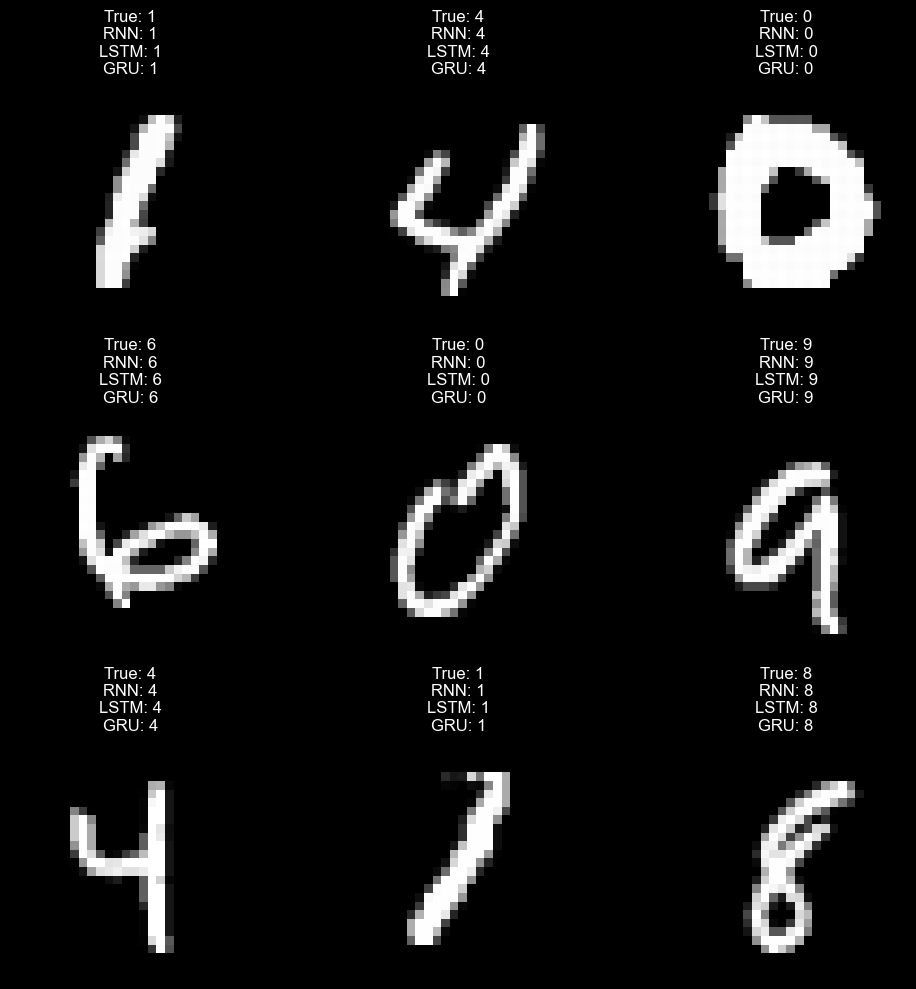

In [19]:
# plot 3 x 3 grid of example from test label + pred
pred_rnn = model_rnn.predict(X_test)
pred_lstm = model_lstm.predict(X_test)
pred_gru = model_gru.predict(X_test)
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i in range(3):
    for j in range(3):
        idx = np.random.randint(X_test.shape[0])
        axes[i, j].imshow(X_test[idx], cmap='gray')
        true_label = y_test[idx]
        pred_label_rnn = np.argmax(pred_rnn[idx])
        pred_label_lstm = np.argmax(pred_lstm[idx])
        pred_label_gru = np.argmax(pred_gru[idx])
        axes[i, j].set_title(f'True: {true_label}\nRNN: {pred_label_rnn}\nLSTM: {pred_label_lstm}\nGRU: {pred_label_gru}')
        axes[i, j].axis('off')
plt.tight_layout()
plt.show()

In [20]:
# load the simple CNN model from the previous notebook and test it on the same test set
model_cnn = keras.models.load_model('mnist_cnn_model.h5')

In [21]:
# test the CNN model
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(X_test, y_test)
print(f'CNN Test accuracy: {test_acc_cnn:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9858 - loss: 0.0494
CNN Test accuracy: 0.9858


In [22]:
# compare where CNN is better than RNN, LSTM and GRU by plotting the misclassified samples for each model
# compare where the RNN, LSTM and GRU are better than CNN by plotting the misclassified samples for each model
pred_cnn = model_cnn.predict(X_test)
misclassified_cnn = np.where(np.argmax(pred_cnn, axis=1) != y_test)[0]
misclassified_rnn = np.where(np.argmax(pred_rnn, axis=1) != y_test)[0]
misclassified_lstm = np.where(np.argmax(pred_lstm, axis=1) != y_test)[0]
misclassified_gru = np.where(np.argmax(pred_gru, axis=1) != y_test)[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 978us/step


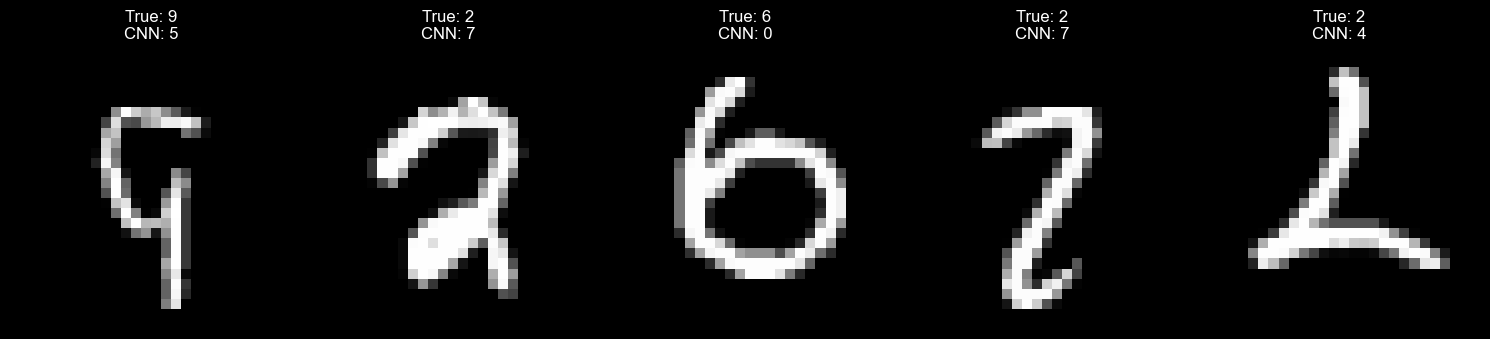

In [23]:
# plot misclassified samples for CNN
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    idx = misclassified_cnn[i]
    axes[i].imshow(X_test[idx], cmap='gray')
    true_label = y_test[idx]
    pred_label_cnn = np.argmax(pred_cnn[idx])
    axes[i].set_title(f'True: {true_label}\nCNN: {pred_label_cnn}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

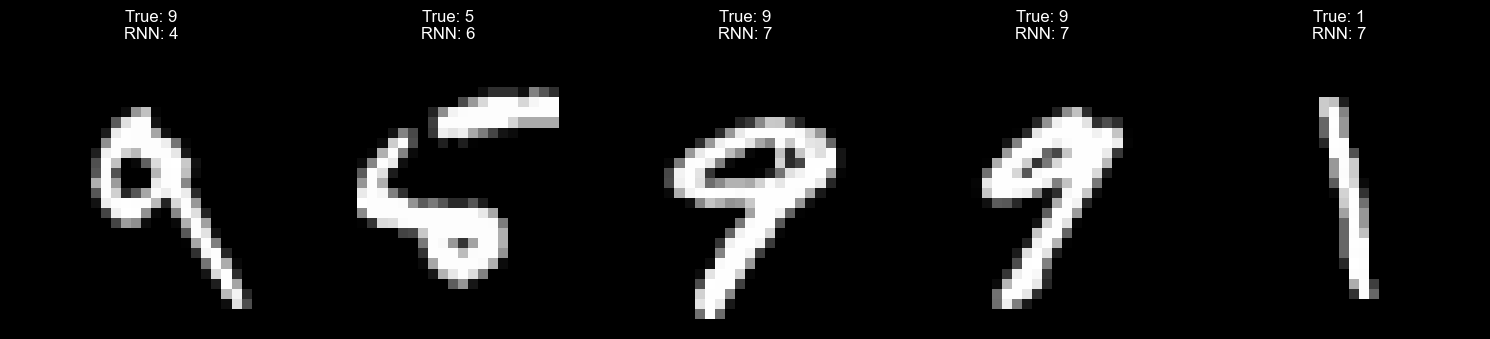

In [24]:
# plot misclassified samples for RNN
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    idx = misclassified_rnn[i]
    axes[i].imshow(X_test[idx], cmap='gray')
    true_label = y_test[idx]
    pred_label_rnn = np.argmax(pred_rnn[idx])
    axes[i].set_title(f'True: {true_label}\nRNN: {pred_label_rnn}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

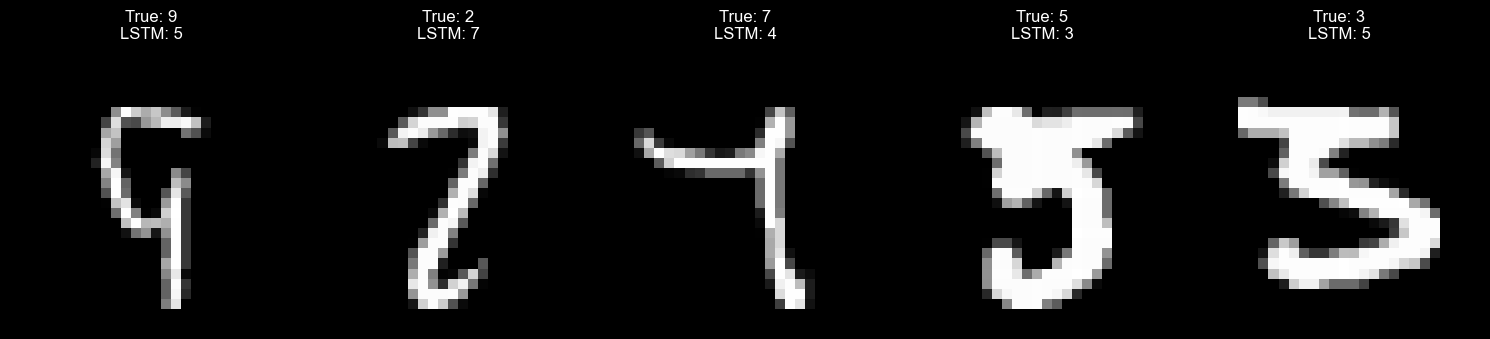

In [25]:
# plot misclassified samples for LSTM
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    idx = misclassified_lstm[i]
    axes[i].imshow(X_test[idx], cmap='gray')
    true_label = y_test[idx]
    pred_label_lstm = np.argmax(pred_lstm[idx])
    axes[i].set_title(f'True: {true_label}\nLSTM: {pred_label_lstm}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

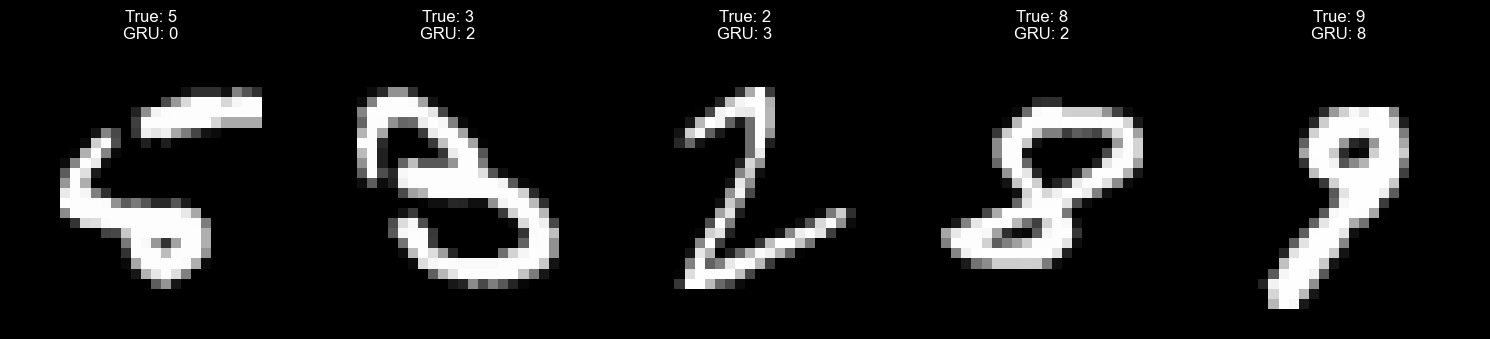

In [26]:
# plot the misclassified samples for GRU
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    idx = misclassified_gru[i]
    axes[i].imshow(X_test[idx], cmap='gray')
    true_label = y_test[idx]
    pred_label_gru = np.argmax(pred_gru[idx])
    axes[i].set_title(f'True: {true_label}\nGRU: {pred_label_gru}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [27]:
# save all models to file
model_rnn.save('mnist_rnn_model.h5')
model_lstm.save('mnist_lstm_model.h5')
model_gru.save('mnist_gru_model.h5')